<a href="https://www.kaggle.com/code/immadirohan/credit-card-project-using-ml?scriptVersionId=303201900" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Dataset loaded successfully
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.mont

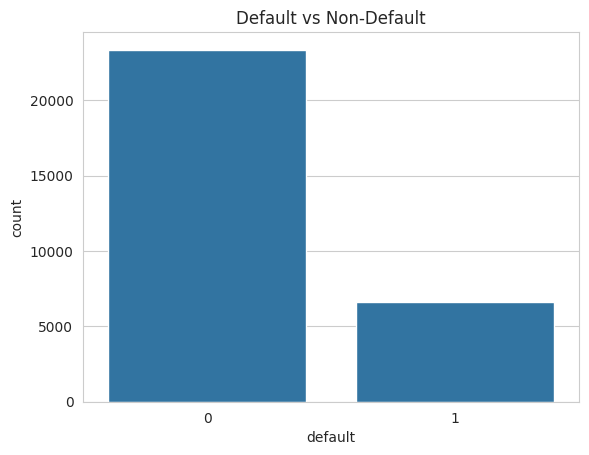

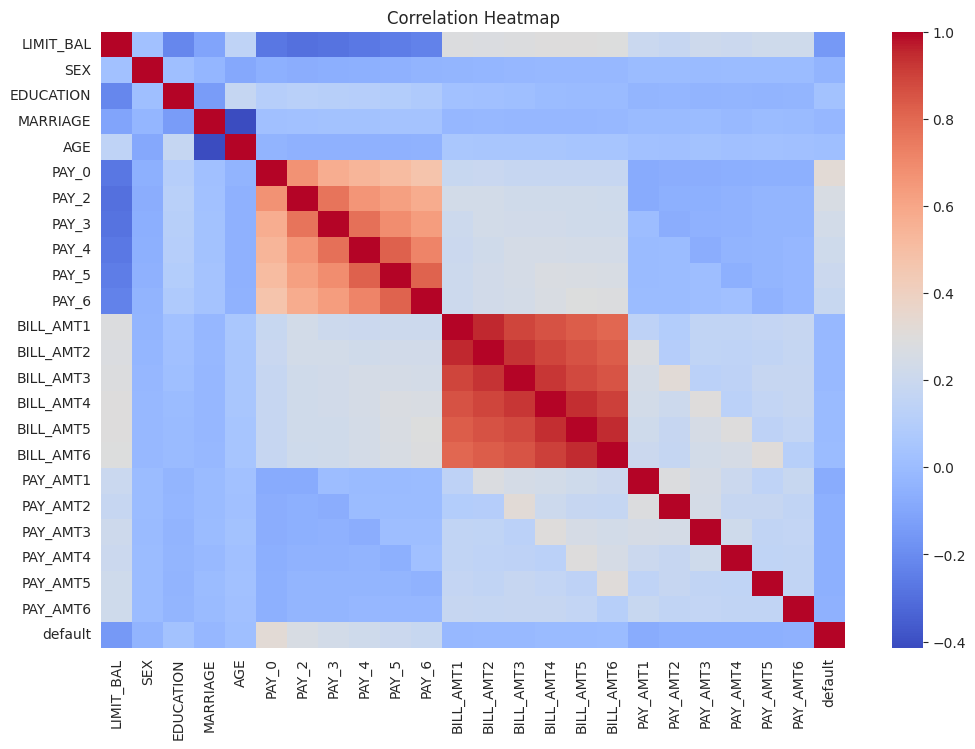


Model training completed

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000


Confusion Matrix
[[4549  138]
 [1002  311]]


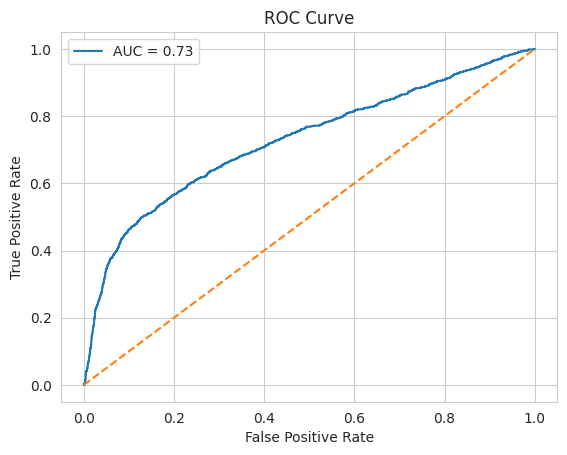

In [1]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

sns.set_style("whitegrid")


# -------------------------------
# 1. Load Dataset
# -------------------------------

# kaggle datasets are stored in /kaggle/input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for file in filenames:
        path = os.path.join(dirname, file)

df = pd.read_csv(path)

print("Dataset loaded successfully")
print(df.head())


# -------------------------------
# 2. Basic Cleaning
# -------------------------------

# rename target column for simplicity
df.rename(columns={'default.payment.next.month':'default'}, inplace=True)

# remove ID column (not useful for prediction)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print("\nColumns after cleaning:")
print(df.columns)


# -------------------------------
# 3. Data Overview
# -------------------------------

print("\nDataset info")
print(df.info())

print("\nStatistical summary")
print(df.describe())


# -------------------------------
# 4. Class Distribution
# -------------------------------

plt.figure()
sns.countplot(x='default', data=df)
plt.title("Default vs Non-Default")
plt.show()


# -------------------------------
# 5. Correlation Heatmap
# -------------------------------

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# -------------------------------
# 6. Feature and Target
# -------------------------------

X = df.drop('default', axis=1)
y = df['default']


# -------------------------------
# 7. Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -------------------------------
# 8. Feature Scaling
# -------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------------------
# 9. Train Model
# -------------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("\nModel training completed")


# -------------------------------
# 10. Predictions
# -------------------------------

y_pred = model.predict(X_test)


# -------------------------------
# 11. Evaluation
# -------------------------------

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


# -------------------------------
# 12. ROC Curve
# -------------------------------

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()